# Index Replication

This notebook investigates the replication of trend-following indices by implementing a range of trend-following strategies proposed in the academic literature alongside commonly used industry methodologies. The objective is to construct a transparent, rules-based replication framework that captures the return characteristics of established trend-following benchmarks.

# Package, Path Management, and Data Load

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [2]:
epost_path = os.getcwd()
res_path   = os.path.abspath(os.path.join(epost_path, ".."))
root_path  = os.path.abspath(os.path.join(res_path, ".."))
data_path  = os.path.join(root_path, "data")
trend_path = os.path.join(data_path, "TrendIndices")
tick_path  = os.path.join(trend_path, "TrendIndicesGuide.xlsx")
fut_path   = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")

In [3]:
df_idx_ticker = (pd.read_excel(
    io         = tick_path,
    sheet_name = "TrendIndices").
    dropna().
    query("Holding == 'Multi Period'").
    query("Currency == 'USD'").
    drop(columns = ["Currency", "Holding"]).
    rename(columns = {"Asset Class": "asset_class"}).
    query("asset_class != 'Volatility'"))

In [4]:
df_ticker_replication_guide = (pd.read_excel(
    io = tick_path, sheet_name = "IndexReplication"))

In [5]:
def _fix_fx(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (df.sort_index().assign(
        fx_val  = lambda x: x.fx_val.ffill(),
        adj_val = lambda x: x.fx_val * x.CLEAN_PX))

    return df_out

df_fut_prep = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    set_index("date").
    groupby("ticker").
    apply(_fix_fx).
    reset_index())

# Analzying Trend Indices

In [6]:
trend_idx_path = os.path.join(trend_path, "RawTrendIndices.parquet")
idx_tickers    = df_idx_ticker.Ticker.drop_duplicates().sort_values().to_list()

df_raw_trend_idx   = (pd.read_parquet(
    path = trend_idx_path, engine = "pyarrow").
    query("security == @idx_tickers"))

In [7]:
idx_renamer = (df_idx_ticker.set_index(
    "Ticker").
    PlotName.
    to_dict())

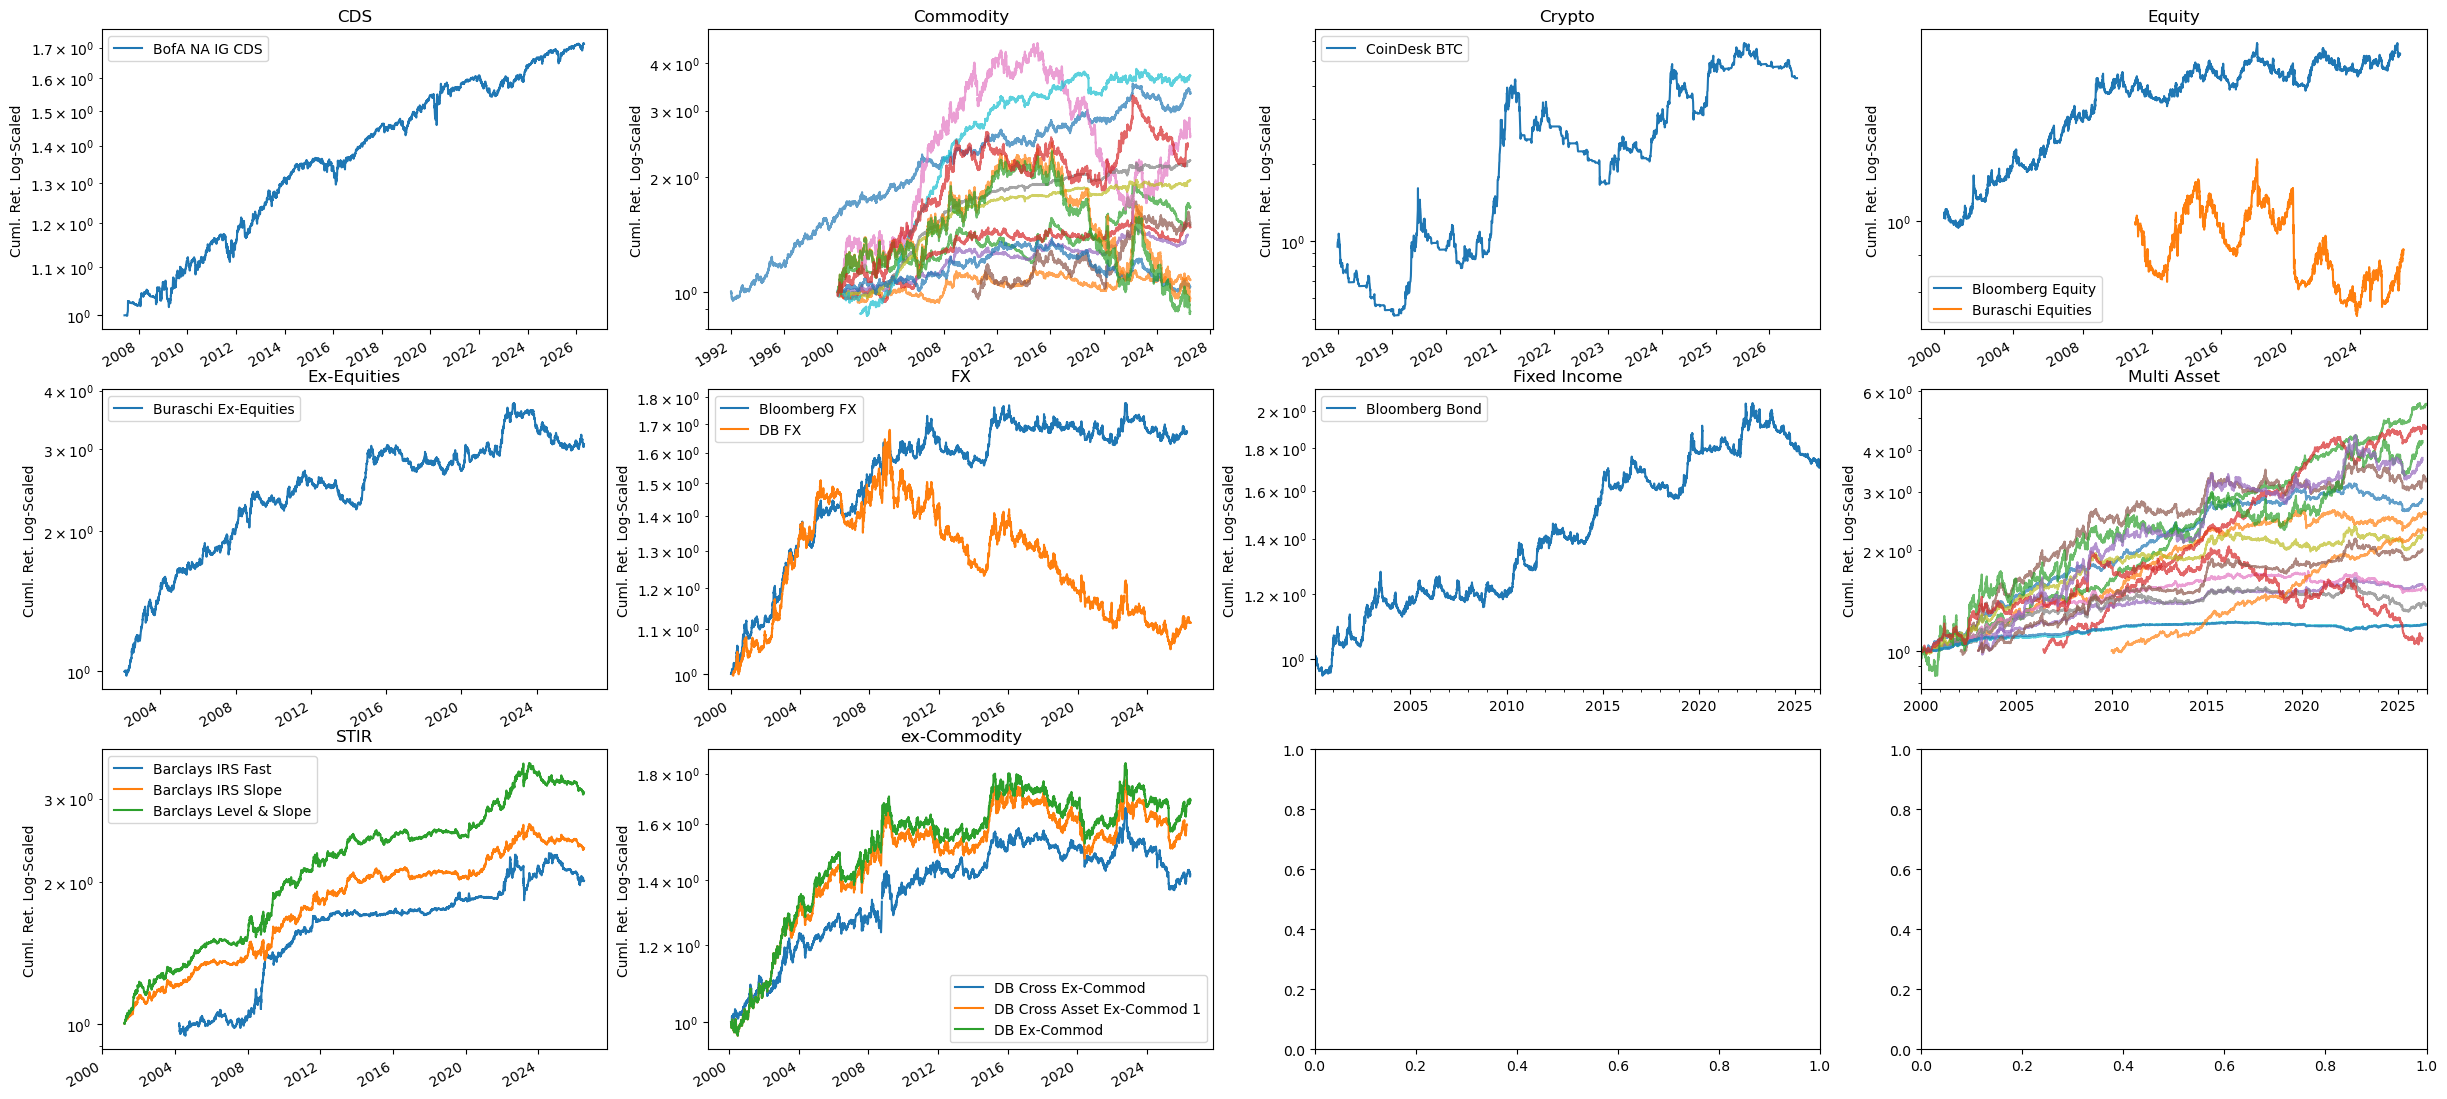

In [8]:
asset_classes = df_idx_ticker.asset_class.drop_duplicates().sort_values().to_list()
fig, axes     = plt.subplots(ncols = 4, nrows = 3, figsize = (30,15))

for asset_class, ax in zip(asset_classes, axes.flatten()):

    tmp_tickers = (df_idx_ticker.query(
        "asset_class == @asset_class").
        Ticker.
        drop_duplicates().
        sort_values().
        to_list())

    if len(tmp_tickers) > 5:
        legend = False
        alpha  = 0.7

    else: 
        legend = True
        alpha  = 1
    
    (df_raw_trend_idx.query(
        "security == @tmp_tickers").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "PX_LAST").
        rename(columns = idx_renamer).
        pct_change().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            title  = asset_class,
            legend = legend,
            alpha  = alpha,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            xlabel = ""))

# Replicating Trend Following Returns

Two data providers appear to have the best data the first is Societe Generale and Bloomberg. 

In [10]:
df_trend_prep = (df_raw_trend_idx.rename(
    columns = {"security": "Ticker"}).
    merge(right = df_idx_ticker, how = "inner", on = ["Ticker"]).
    query("Provider == ['Societe Generale', 'Bloomberg']").
    drop(columns = ["File", "BBG Index Provider", "Name"]))

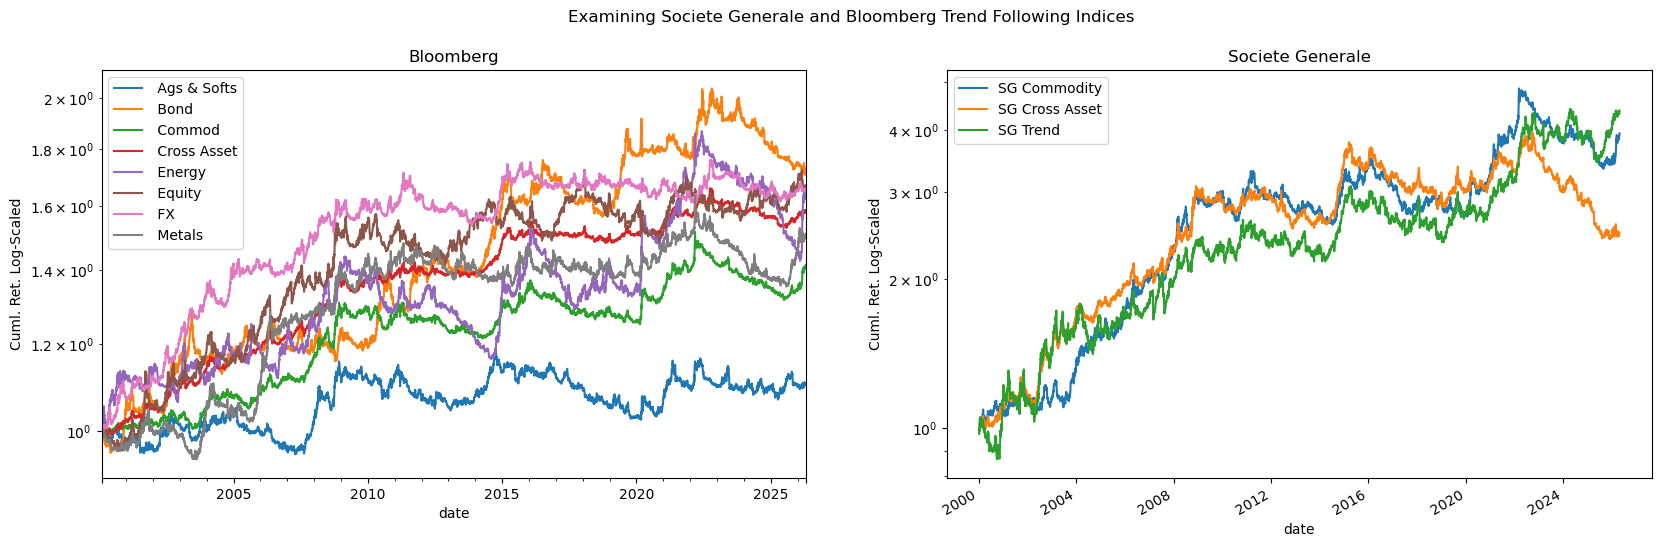

In [11]:
providers = df_trend_prep.Provider.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(providers), figsize = (20,6))

for provider, ax in zip(providers, axes.flatten()): 

    (df_trend_prep.query(
        "Provider == @provider").
        assign(PlotName = lambda x: x.PlotName.str.replace(provider, "")).
        rename(columns = {"PlotName": ""}).
        pivot(index = "date", columns = "", values = "PX_LAST").
        dropna().
        pct_change().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            title  = provider,
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Examining Societe Generale and Bloomberg Trend Following Indices")
plt.show()

# Raw signal reconstruction

In this case using the approach of Dao, T.-L., Nguyen, T.-T., Deremble, C., Lempérière, Y., Bouchaud, J.-P., & Potters, M, which is researched in this current repository [Trend Convexity Jupyter Notebook](https://github.com/diegodalvarez/TrendSystem/blob/main/Research/Whitepapers/DaoNguyenDerembleLemperiereBouchaudPottersTrendConvexity.ipynb.ipynb). Start by using the signal that they propose from their universe selection and then reconstruct the index. For now we'll not focus on whether or not we can implement it yet, but instead focus on how well we can replicate the returns so we'll use contemperanously hedged returns as opposed to lagged. From the prior notebook contemperanously hedged returns adds a small (but reasonable) amount of increased correlation. We'll also use scaled signal weights as opposed to binary (capped) positions. 

In [29]:
dao_tickers = (df_ticker_replication_guide.query(
    "group == 'TLDao'").
    assign(ticker = lambda x: x.ticker.str.replace(" 1", "1").str.lower().str.replace(" ", "_")).
    ticker.
    drop_duplicates().
    sort_values().
    to_list())

In [33]:
signal_path   = os.path.join(data_path, "Signals", "DaoNguyenDerembleLemperiereBouchaudPotters.parquet")
df_signal_raw = pd.read_parquet(path = signal_path, engine = "pyarrow")
df_dao_rtn    = df_signal_raw.query("ticker == @dao_tickers")

Let's start with the multi-asset indices first. 

In [184]:
df_dao_ind = (
    df_dao_rtn[
        ["date", "ticker", "lag_signal", "px_rtn"]
    ]
    .assign(
        date=lambda x: pd.to_datetime(x.date),
        signal_rtn=lambda x: x.lag_signal * x.px_rtn,
    )
)

df_signal_rtn_wider = (
    df_dao_ind.pivot(
        index="date",
        columns="ticker",
        values="signal_rtn",
    )
)

In [185]:
window = 100

# Equal-weight portfolio before volatility targeting
port = df_signal_rtn_wider.mean(axis=1)

# Portfolio volatility
port_vol = (
    port
    .ewm(span=window, adjust=False)
    .std()
    * np.sqrt(252)
)

df_multi_trend = (
    df_trend_prep.query("asset_class == 'Multi Asset'")
    .pivot(index="date", columns="PlotName", values="PX_LAST")
    .pct_change()
)

df_vol_target = (
    df_multi_trend
    .apply(lambda x: x.ewm(span=window, adjust=False).std() * np.sqrt(252))
)

In [191]:
benchmarks = df_stds.PlotName.drop_duplicates().sort_values().to_list()
df_lists   = []

for benchmark in benchmarks:

    df_tmp = (
        port.rename("port")
        .to_frame()
        .join(port_vol.rename("port_vol"))
        .join(df_multi_trend[[benchmark]])
        .join(
            df_vol_target[[benchmark]].rename(
                columns={benchmark: "target_vol"}
            )
        )
        .dropna()
        .assign(
            weight=lambda x: x.target_vol / x.port_vol,
            port=lambda x: x.port * x.weight,
        )
    )

    df_add = (
        df_tmp[["port", benchmark]]
        .rename(columns = {"port": "DaoPort"})
        .reset_index()
        .melt(id_vars = ["date", "DaoPort"]))

    df_lists.append(df_add)

In [193]:
df_compare = (pd.concat(df_lists))

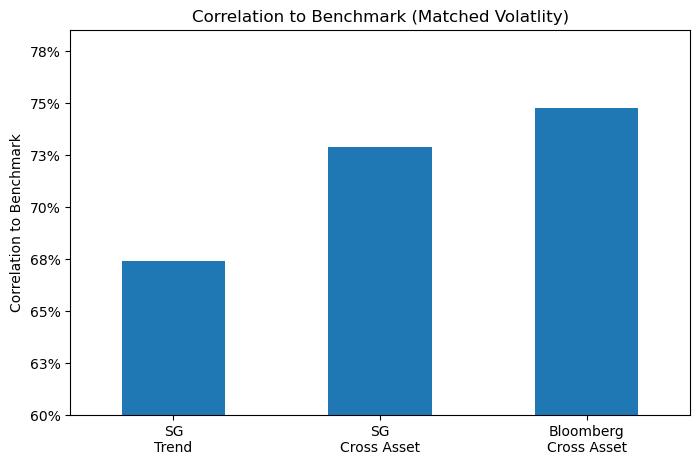

In [211]:
fig, axes = plt.subplots(figsize = (8,5))

(df_compare.drop(
    columns = ["date"]).
    groupby("variable").
    agg("corr").
    reset_index().
    query("value != 1").
    assign(variable = lambda x: x.variable.str.replace("SG ", "SG\n").str.replace("Bloomberg ", "Bloomberg\n")).
    set_index("variable")
    [["value"]].
    sort_values("value").
    plot(
        ax     = axes,
        kind   = "bar",
        rot    = 0,
        xlabel = "",
        ylabel = "Correlation to Benchmark",
        legend = False,
        ylim   = 0.6,
        title  = "Correlation to Benchmark (Matched Volatlity)"))

axes.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}"))

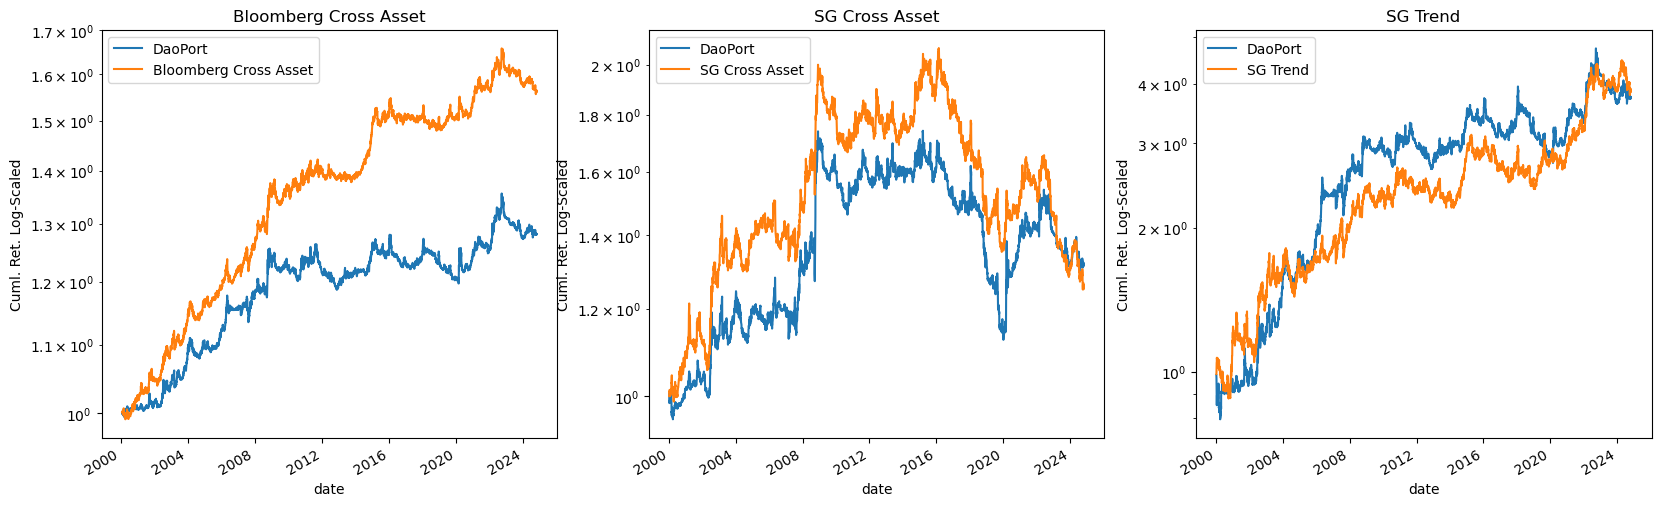

In [229]:
benchmarks = df_compare.variable.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(benchmarks), figsize = (20,6))

for benchmark, ax in zip(benchmarks, axes.flatten()): 

    (df_compare.query(
        "variable == @benchmark").
        rename(columns = {"variable": ""}).
        pivot(index = ["date", "DaoPort"], columns = "", values = "value").
        reset_index().
        set_index("date").
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = benchmark))

# References

@article{dao2017tail,
  title   = {Tail Protection for Long Investors: Trend Convexity at Work},
  author  = {Dao, Tung-Lam and Nguyen, Trung-Tu and Deremble, Cyril and Lemp{\'e}ri{\`e}re, Yves and Bouchaud, Jean-Philippe and Potters, Marc},
  journal = {Journal of Investment Strategies},
  volume  = {7},
  number  = {1},
  pages   = {61--84},
  year    = {2017},
  doi     = {10.21314/JOIS.2017.093}
}